<img src="../Images/DSC_Logo.png" style="width: 400px;">

# Basics of Quantitative Data Analysis in Python
# - Loading Files & Data Structures

Research often starts with existing data files: for example tables from surveys, lab measurements, sensor time series, administrative records, or model outputs. Before data can be analyzed, it first has to be loaded correctly and understood in a suitable structure.

This notebook introduces the basic ways to work with quantitative data in Python. We focus on:
- loading common file types such as **text files** for simple file input/output
- understanding key data structures for quantitative work: **dataframes** with `pandas` for tabular data and **arrays** with `numpy` for numerical data
- inspecting and selecting data
- converting between structures when needed

The main goal is not yet to analyze data, but to learn how to bring data into Python in a structured and reproducible way.

In [5]:
# Install all required libraries for this notebook:

!pip install -q -r ../requirements_B.txt   

print("The libraries have been installed.")

The libraries have been installed.


## 1. Reading and Writing Text Files

In research, data is often stored in files rather than created directly in code. While many quantitative datasets are later loaded with libraries such as `pandas`, it is still useful to understand the basic Python way of opening and writing files.

Python provides the built-in function `open()` for this purpose. It is commonly used together with a `with` statement, which automatically closes the file again after use.

Let's **open** a file (from a relative path) in `read` mode and store its contents in the variable `data`:

In [6]:
with open("../Data/DataB/Iris.csv", "r") as f: 
    data = f.read()

print(data)

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
6,5.4,3.9,1.7,0.4,Iris-setosa
7,4.6,3.4,1.4,0.3,Iris-setosa
8,5.0,3.4,1.5,0.2,Iris-setosa
9,4.4,2.9,1.4,0.2,Iris-setosa
10,4.9,3.1,1.5,0.1,Iris-setosa
11,5.4,3.7,1.5,0.2,Iris-setosa
12,4.8,3.4,1.6,0.2,Iris-setosa
13,4.8,3.0,1.4,0.1,Iris-setosa
14,4.3,3.0,1.1,0.1,Iris-setosa
15,5.8,4.0,1.2,0.2,Iris-setosa
16,5.7,4.4,1.5,0.4,Iris-setosa
17,5.4,3.9,1.3,0.4,Iris-setosa
18,5.1,3.5,1.4,0.3,Iris-setosa
19,5.7,3.8,1.7,0.3,Iris-setosa
20,5.1,3.8,1.5,0.3,Iris-setosa
21,5.4,3.4,1.7,0.2,Iris-setosa
22,5.1,3.7,1.5,0.4,Iris-setosa
23,4.6,3.6,1.0,0.2,Iris-setosa
24,5.1,3.3,1.7,0.5,Iris-setosa
25,4.8,3.4,1.9,0.2,Iris-setosa
26,5.0,3.0,1.6,0.2,Iris-setosa
27,5.0,3.4,1.6,0.4,Iris-setosa
28,5.2,3.5,1.5,0.2,Iris-setosa
29,5.2,3.4,1.4,0.2,Iris-setosa
30,4.7,3.2,1.6,0.2,Iris-setosa
31,4.8,3.1,1.6

To **save** data into a new file, we change the mode to `write`:

In [7]:
new_string = "These are my notes on experiment A."

with open("../Data/DataB/Notes.txt", "w") as f:
    f.write(new_string)

However, this way of reading and writing files does not interpret comma-separated values automatically. If you want to work with structured tabular data such as CSV files, it is better to use libraries such as `csv` or `pandas` (Sect. 2).

## 2. File Organization and Batch Processing

In many research projects, data is stored across multiple files and folders. Instead of opening each file manually, it is often more efficient and less error-prone to work with paths programmatically and **process groups of files** automatically.

Python’s `pathlib` library helps define files and folders clearly and makes code for file handling easier to read.






In [8]:
from pathlib import Path    # Import library (Python built-in)

Define the "Samples" folder:

In [9]:
sample_dir = Path("../Data/DataB/Samples")  

The `glob` method can be used to search for files that match a specific pattern. In the example below, we use `glob` to search for all .txt files in the "Samples" folder:

In [10]:
files = sample_dir.glob("*.txt")

?:

In [11]:
for filepath in files:
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()
        print(content)

5663
4456
1864
3657
8735


---
### **Exercise 1:**  
Please answer the following questions about the code above. Write your answers in **Markdown** in the `:?` cell above the code.

- Which basic Python structure is used here to repeat steps several times?
- What happens in the code each time the steps are repeated?
- How could you make the code repeat more times?

Solution: 
- The code uses a **`for` loop**.
- It goes through all text files in a folder, opens each file, reads its content, and prints the content to the screen.
- The code repeats more times if `files` contains more file paths, for example because more matching text files are placed in the folder.

---

## 3. Tabular Data / `pandas`

## 3.1 Basics

Because many quantitative datasets can be represented as tables, the **dataframe** is often the most important structure to learn first. Datasets such as survey results, administrative records, lab measurements, or outputs from instruments and models are often stored in a tabular format, with rows representing observations and columns representing variables.

The Python library `pandas` is designed for working with this kind of tabular data and is the most widely used tool for it in Python. `pandas` reads files such as .csv or Excel spreadsheets into dataframes, which keep both the data and its structure intact.

<img src="../Images/dataframe.png" style="width: 300px;">

In [12]:
import pandas as pd     # Import library (must be installed)

To **create** a dataframe (`DataFrame`) from a dictionary:

In [13]:
names_dict = {"numbers": [1, 2, 3, 4, 5, 6]}
df = pd.DataFrame(names_dict)

print(df)

   numbers
0        1
1        2
2        3
3        4
4        5
5        6


To **save** a dataframe to CSV:

In [14]:
df.to_csv("../Data/DataB/numbers.csv", index=False)     # Setting `index=False` prevents pandas from writing row indices to the file.

When **importing** tabular data, common adjustments include:
- choosing a separator, e.g. `sep=";"` instead of comma
- skipping metadata rows with `skiprows=...`
- specifying missing-value markers with `na_values=...`
- reading a specific Excel sheet with `sheet_name=...`

For the text file example from Section 1, none of these import adjustments are needed. In practice, however, it is always important to check such settings in advance.

In [15]:
Iris = pd.read_csv("../Data/DataB/Iris.csv")

print(Iris)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..              ...  
145  

When loading a new dataset, the first step is usually not analysis, but inspection: checking dimensions, column names, data types, and a few example rows. Once the data are in a dataframe, we can check:

- How many rows and columns do we have?

In [16]:
print(Iris.shape)   # (number_of_rows, number_of_columns)

(150, 6)


- What columns exist in this dataframe?

In [17]:
print(Iris.columns)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


- 10 randomly selected rows:

In [18]:
Iris.sample(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
66,67,5.6,3.0,4.5,1.5,Iris-versicolor
28,29,5.2,3.4,1.4,0.2,Iris-setosa
24,25,4.8,3.4,1.9,0.2,Iris-setosa
80,81,5.5,2.4,3.8,1.1,Iris-versicolor
140,141,6.7,3.1,5.6,2.4,Iris-virginica
56,57,6.3,3.3,4.7,1.6,Iris-versicolor
112,113,6.8,3.0,5.5,2.1,Iris-virginica
120,121,6.9,3.2,5.7,2.3,Iris-virginica
44,45,5.1,3.8,1.9,0.4,Iris-setosa
137,138,6.4,3.1,5.5,1.8,Iris-virginica


A dataframe follows Python’s usual indexing logic, so we can, for example, **select** a specific column either by its name or its position (index).

- Select a column by name:

In [19]:
species = Iris["Species"]

print(species)

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object


- Select the first column by its index position (column 0):

In [20]:
first_column = Iris.iloc[:, 0]

print(first_column)

0        1
1        2
2        3
3        4
4        5
      ... 
145    146
146    147
147    148
148    149
149    150
Name: Id, Length: 150, dtype: int64


- Select the first row by its index position (row 0):

In [21]:
first_row = Iris.iloc[0, :]

print(first_row)

Id                         1
SepalLengthCm            5.1
SepalWidthCm             3.5
PetalLengthCm            1.4
PetalWidthCm             0.2
Species          Iris-setosa
Name: 0, dtype: object


We can also **add data** to an existing dataframe. 

- Add a new empty column with missing values:

In [22]:
Iris["Notes"] = pd.NA

print(Iris)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species Notes  
0       Iris-setosa  <NA>  
1       Iris-setosa  <NA>  
2       Iris-setosa  <NA>  
3       Iris-setosa  <NA>  
4       Iris-setosa

- Fill a few rows:

In [23]:
Iris.loc[0:2, "Notes"] = "check"

Iris.head()      # .head() displays only the first five rows; also check out .tail() and .sample()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Notes
0,1,5.1,3.5,1.4,0.2,Iris-setosa,check
1,2,4.9,3.0,1.4,0.2,Iris-setosa,check
2,3,4.7,3.2,1.3,0.2,Iris-setosa,check
3,4,4.6,3.1,1.5,0.2,Iris-setosa,<NA>
4,5,5.0,3.6,1.4,0.2,Iris-setosa,<NA>


---

### **Exercise 2:** 

`pandas` can also be used to import other tabular file formats, including **Excel files**. Instead of `pd.read_csv()`, use `pd.read_excel()` to import the file `World-happiness-report-2024.xlsx` as a dataframe. Then print all column names and select one column.

In [24]:
# Solution:

# Load the file as a pandas dataframe
report = pd.read_excel("../Data/DataB/World-happiness-report-2024.xlsx") 

# Print all column names
print(report.columns)

# Select one column
country_name = report.iloc[:, 0]
print(country_name)

Index(['Country name', 'Regional indicator', 'Ladder score', 'upperwhisker',
       'lowerwhisker', 'Log GDP per capita', 'Social support',
       'Healthy life expectancy', 'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Dystopia + residual'],
      dtype='object')
0               Finland
1               Denmark
2               Iceland
3                Sweden
4                Israel
             ...       
138    Congo (Kinshasa)
139        Sierra Leone
140             Lesotho
141             Lebanon
142         Afghanistan
Name: Country name, Length: 143, dtype: object


---

There are several ways to **put tabular data together** in `pandas`. For example, `concat()` can stack dataframes, while `merge()` combines them based on shared keys or IDs.  

Below, we see a simple example with `merge()`. For more options, see the pandas documentation: [Merge, join, concatenate and compare](https://pandas.pydata.org/docs/user_guide/merging.html)

In [25]:
# Create first dataframe
scores = pd.DataFrame({
    "ID": [1, 2, 3],
    "Score": [12, 15, 14]
})

# Create second dataframe
groups = pd.DataFrame({
    "ID": [1, 2, 3],
    "Group": ["A", "B", "A"]
})

# Merge both dataframes using the shared ID column
merged_data = pd.merge(scores, groups, on="ID")  # <-
print(merged_data)

   ID  Score Group
0   1     12     A
1   2     15     B
2   3     14     A


## 3.2 Wide and Long Data Format

Tabular data can be organized in different ways. Two common formats are wide and long:
- In **wide format**, repeated measurements are spread across several columns.
- In **long format**, each row represents one observation at one measurement occasion, and repeated measurements are stored in a single measurement column together with an additional column indicating time, condition, or category.

Many plotting, grouping, and modeling functions in Python work especially well with long-format data.

Below, we create a dataframe where each participant of a survey appears only once, and the repeated measurements are stored in separate columns (wide format):

In [26]:
wide_data = pd.DataFrame({
    "participant_id": ["P01", "P02", "P03"],
    "score_t1": [12, 15, 14],
    "score_t2": [13, 16, 15]
})

print(wide_data)

  participant_id  score_t1  score_t2
0            P01        12        13
1            P02        15        16
2            P03        14        15


The function `.melt()` **reshapes** the table from wide format to long format. In the long format, each participant can appear multiple times, and the repeated measurements are stored in separate rows (not separate columns).

In [27]:
long_data = wide_data.melt(
    id_vars="participant_id",
    var_name="time",
    value_name="score"
)

print(long_data)

  participant_id      time  score
0            P01  score_t1     12
1            P02  score_t1     15
2            P03  score_t1     14
3            P01  score_t2     13
4            P02  score_t2     16
5            P03  score_t2     15


Reshape long format back to wide format with `.pivot()`:

In [28]:
wide_data = long_data.pivot(
    index="participant_id",
    columns="time",
    values="score"
)

print(wide_data)

time            score_t1  score_t2
participant_id                    
P01                   12        13
P02                   15        16
P03                   14        15


## 4. Data Arrays / `numpy`

While `pandas` dataframes are ideal for tabular datasets with named columns, many scientific applications also use **arrays**. These are especially useful when data has a regular numerical structure, such as vectors, matrices, images, or gridded values.

The `numpy` library provides the core array structure used throughout Python. Many other Python libraries are built on top of `numpy`, including `pandas`. 

Arrays can be one-dimensional, two-dimensional, or have even more dimensions. The **shape of an array** is very important. Many operations only work when array shapes are compatible. The exact requirement depends on the task.

<img src="../Images/array.png" style="width: 600px;"> <img src="../Images/pandas_numpy.png" style="width: 300px;">

In [29]:
import numpy as np      # Import library (must be installed)

Let's **import** some data (temperature anomaly time series) as a 2D NumPy array:

In [30]:
time_series = np.loadtxt('../Data/DataB/NOAA_time_series.csv', skiprows=5, delimiter=',')

print(time_series) 

[[ 1.850e+03 -3.000e-02]
 [ 1.851e+03  7.000e-02]
 [ 1.852e+03  8.000e-02]
 [ 1.853e+03  1.300e-01]
 [ 1.854e+03  0.000e+00]
 [ 1.855e+03 -1.200e-01]
 [ 1.856e+03 -1.400e-01]
 [ 1.857e+03 -1.600e-01]
 [ 1.858e+03 -1.400e-01]
 [ 1.859e+03 -1.300e-01]
 [ 1.860e+03 -2.100e-01]
 [ 1.861e+03 -1.500e-01]
 [ 1.862e+03 -2.700e-01]
 [ 1.863e+03 -2.300e-01]
 [ 1.864e+03 -9.000e-02]
 [ 1.865e+03  1.000e-02]
 [ 1.866e+03  0.000e+00]
 [ 1.867e+03 -1.800e-01]
 [ 1.868e+03 -8.000e-02]
 [ 1.869e+03 -9.000e-02]
 [ 1.870e+03 -2.000e-02]
 [ 1.871e+03 -2.000e-02]
 [ 1.872e+03 -1.000e-01]
 [ 1.873e+03 -8.000e-02]
 [ 1.874e+03 -2.300e-01]
 [ 1.875e+03 -9.000e-02]
 [ 1.876e+03 -1.700e-01]
 [ 1.877e+03  2.900e-01]
 [ 1.878e+03  2.200e-01]
 [ 1.879e+03 -1.000e-02]
 [ 1.880e+03 -2.100e-01]
 [ 1.881e+03  0.000e+00]
 [ 1.882e+03 -2.100e-01]
 [ 1.883e+03 -8.000e-02]
 [ 1.884e+03 -3.300e-01]
 [ 1.885e+03 -2.600e-01]
 [ 1.886e+03 -1.800e-01]
 [ 1.887e+03 -2.600e-01]
 [ 1.888e+03 -1.000e-02]
 [ 1.889e+03 -7.000e-02]


Let's see how to inspect the **structure** of an array!

- Size of each dimension:

In [31]:
print(time_series.shape)

(175, 2)


- Number of dimensions:

In [32]:
print(time_series.ndim)

2


- Data type of the stored values:

In [33]:
print(time_series.dtype)

float64


To **create** a 2D NumPy array from scratch:

In [34]:
data = np.array([
    [1, 0, 0, 1],
    [1, 0, 1, 1],
    [0, 1, 1, 1],
    [0, 0, 0, 1]
])

print(data.shape)

(4, 4)


Now we import `matplotlib` to quickly **visualize** our NumPy array and make its structure (rows, columns, and patterns) easier to understand.

In [35]:
import matplotlib.pyplot as plt     # Import library (must be installed)

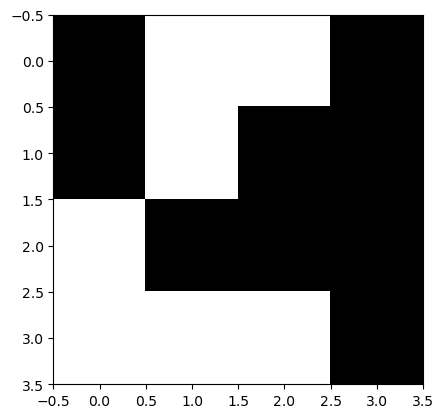

In [36]:
plt.imshow(data, plt.cm.gray_r)

Below, we aim to **select** only parts of the array/image.

- First element/cell:

In [37]:
print(data[0, 0])

1


- First two rows and first two columns:

In [38]:
print(data[0:2,0:2])

[[1 0]
 [1 0]]


There are also several ways to **manipulate and combine arrays** in `numpy`, for example by adding, stacking, reshaping, or concatenating data.  

Below is one simple example for adding a new row to the `data` array, but many other options are available in the NumPy documentation: [Array manipulation routines](https://numpy.org/doc/stable/reference/routines.array-manipulation.html#).

In [39]:
# Create the new row as a NumPy array
new_row = np.array([[1, 1, 1, 1]])

# Stack the arrays vertically to add the new row
data = np.vstack([data, new_row])

print(data)

[[1 0 0 1]
 [1 0 1 1]
 [0 1 1 1]
 [0 0 0 1]
 [1 1 1 1]]


NumPy can also handle **multi-dimensional data**, such as 3D arrays, which are useful for representing things like image stacks or time-varying data. Here's a basic example for creating a 3D array: 2 "layers", each 3x3:

In [40]:
data = np.array([
    [[1, 2, 3],
     [4, 5, 6],
     [7, 8, 9]],

    [[10, 11, 12],
     [13, 14, 15],
     [16, 17, 18]]
])

print(data.shape)

(2, 3, 3)


---
### **Exercise 3:** 

Create a small 2D NumPy array (e.g., 9×9) filled with zeros, then turn some cells into 1s so that `plt.imshow()` shows a circle/ring.

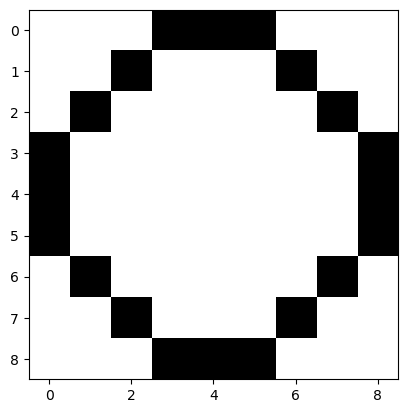

In [41]:
# Solution:

# Create 2D NumPy array
data = np.array([
    [0,0,0,1,1,1,0,0,0],
    [0,0,1,0,0,0,1,0,0],
    [0,1,0,0,0,0,0,1,0],
    [1,0,0,0,0,0,0,0,1],
    [1,0,0,0,0,0,0,0,1],
    [1,0,0,0,0,0,0,0,1],
    [0,1,0,0,0,0,0,1,0],
    [0,0,1,0,0,0,1,0,0],
    [0,0,0,1,1,1,0,0,0],
])

# Plot with matplotlib
plt.imshow(data, plt.cm.gray_r)

---

`numpy` arrays are great for fast numerical operations. However, they lack labels (like column names), which makes dataframes more convenient for data exploration and analysis.

Here is how you can **convert** between the two data structures:

- Convert array to dataframe:

In [42]:
df = pd.DataFrame(time_series, columns=['Year', 'Anomaly'])

df.head()       # .head prints the first 5 rows of the df by default

,Year,Anomaly
0,1850.0,-0.03
1,1851.0,0.07
2,1852.0,0.08
3,1853.0,0.13
4,1854.0,0.00


- Convert dataframe to array:

In [43]:
array_again = df.values
print(array_again[:5]) 

[[ 1.850e+03 -3.000e-02]
 [ 1.851e+03  7.000e-02]
 [ 1.852e+03  8.000e-02]
 [ 1.853e+03  1.300e-01]
 [ 1.854e+03  0.000e+00]]


## 5. More Data Structures: Labelled Multidimensional Data / `xarray`

Some scientific datasets are not best represented as simple tables or unlabeled arrays. For example, climate, remote sensing, or model data often has several labelled dimensions such as time, latitude, and longitude.

The library `xarray` is designed for this type of data. Below, we only take a brief look at the basic idea.

In [44]:
import xarray as xr     # Import library (must be installed)

When working with `xarray`, we distinguish between:
- **dimensions:** the axes along which the data varies, for example time, latitude, and longitude
- **coordinates:** the labels along these dimensions, for example specific dates or latitude values
- **variables:** the actual measured values, for example temperature or precipitation

To illustrate the idea, we can first create a very small labelled data structure from scratch:

In [45]:
temperature = xr.DataArray(
    np.random.rand(3, 4),
    dims=("time", "location"),
    coords={
        "time": ["day1", "day2", "day3"],
        "location": ["A", "B", "C", "D"]
    }
)

print(temperature)

<xarray.DataArray (time: 3, location: 4)> Size: 96B
array([[0.56818327, 0.32615944, 0.52619134, 0.39175794],
       [0.99685023, 0.18835068, 0.23188696, 0.62339241],
       [0.43718277, 0.88865702, 0.50297341, 0.1446831 ]])
Coordinates:
  * time      (time) <U4 48B 'day1' 'day2' 'day3'
  * location  (location) <U1 16B 'A' 'B' 'C' 'D'


Here, the data has two dimensions (`time` and `location`) and labelled coordinates along both axes. This is similar to an array in `numpy`, but with additional labels that make the structure easier to interpret.

Such labelled multidimensional data is often stored in specialized file formats. A common format is **NetCDF**, which is widely used for climate, and other gridded scientific datasets. As an example, we use a small snippet of ERA5 climate reanalysis data, which contains near-surface air temperature values (`t2m`) on a spatial grid over time.

If not unpacked already, the .7z archive containing the NetCDF file first needs to be extracted:

In [46]:
import py7zr        # Import libraries (must be installed)

In [47]:
with py7zr.SevenZipFile('../Data/DataB/ERA5_snippet.7z', mode='r', password='secret') as archive:
    archive.extractall(path='../Data/DataB/')

**Import** the file:

In [48]:
ERA5 = xr.open_dataset('../Data/DataB/ERA5_snippet.nc')
print(ERA5)

<xarray.Dataset> Size: 171MB
Dimensions:    (longitude: 37, latitude: 33, time: 8760)
Coordinates:
  * longitude  (longitude) float32 148B 6.0 6.25 6.5 6.75 ... 14.5 14.75 15.0
  * latitude   (latitude) float32 132B 55.0 54.75 54.5 54.25 ... 47.5 47.25 47.0
  * time       (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
Data variables:
    t2m        (time, latitude, longitude) float64 86MB ...
    tp         (time, latitude, longitude) float64 86MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-08-27 15:32:48 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...


Let's inspect the **structure** of the dataset:

- Show the dimensions of the dataset:

In [49]:
print(ERA5.dims)

FrozenMappingWarningOnValuesAccess({'longitude': 37, 'latitude': 33, 'time': 8760})


- Show the coordinate variables:

In [50]:
print(ERA5.coords)

Coordinates:
  * longitude  (longitude) float32 148B 6.0 6.25 6.5 6.75 ... 14.5 14.75 15.0
  * latitude   (latitude) float32 132B 55.0 54.75 54.5 54.25 ... 47.5 47.25 47.0
  * time       (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00


- Show the data variables stored in the dataset:

In [51]:
print(ERA5.data_vars)

Data variables:
    t2m      (time, latitude, longitude) float64 86MB ...
    tp       (time, latitude, longitude) float64 86MB ...


Let's see how to **select** data in `xarray` multidimensional datasets.

- First, we select t2m, which represents 2 meter air temperature. Selecting a single variable from an `xarray` dataset works similarly to selecting a single column from a `pandas` dataframe:

In [52]:
t2m = ERA5["t2m"]

print(t2m)

<xarray.DataArray 't2m' (time: 8760, latitude: 33, longitude: 37)> Size: 86MB
[10695960 values with dtype=float64]
Coordinates:
  * longitude  (longitude) float32 148B 6.0 6.25 6.5 6.75 ... 14.5 14.75 15.0
  * latitude   (latitude) float32 132B 55.0 54.75 54.5 54.25 ... 47.5 47.25 47.0
  * time       (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
Attributes:
    units:      K
    long_name:  2 metre temperature


- We can also select along dimensions. To select the first time step by index with `.isel()`:

In [53]:
t2m.isel(time=0)

<xarray.DataArray 't2m' (latitude: 33, longitude: 37)> Size: 10kB
[1221 values with dtype=float64]
Coordinates:
  * longitude  (longitude) float32 148B 6.0 6.25 6.5 6.75 ... 14.5 14.75 15.0
  * latitude   (latitude) float32 132B 55.0 54.75 54.5 54.25 ... 47.5 47.25 47.0
    time       datetime64[ns] 8B 2023-01-01
Attributes:
    units:      K
    long_name:  2 metre temperature

- To select a single value by index position with .isel():

In [54]:
t2m.isel(time=0, latitude=0, longitude=0)

<xarray.DataArray 't2m' ()> Size: 8B
[1 values with dtype=float64]
Coordinates:
    longitude  float32 4B 6.0
    latitude   float32 4B 55.0
    time       datetime64[ns] 8B 2023-01-01
Attributes:
    units:      K
    long_name:  2 metre temperature

- To select data by coordinate labels:

In [55]:
t2m.sel(time="2023-01-01")

<xarray.DataArray 't2m' (time: 24, latitude: 33, longitude: 37)> Size: 234kB
[29304 values with dtype=float64]
Coordinates:
  * longitude  (longitude) float32 148B 6.0 6.25 6.5 6.75 ... 14.5 14.75 15.0
  * latitude   (latitude) float32 132B 55.0 54.75 54.5 54.25 ... 47.5 47.25 47.0
  * time       (time) datetime64[ns] 192B 2023-01-01 ... 2023-01-01T23:00:00
Attributes:
    units:      K
    long_name:  2 metre temperature

We **plot** the first time slice of temperature (t2m) to get a better understanding of the data structure:

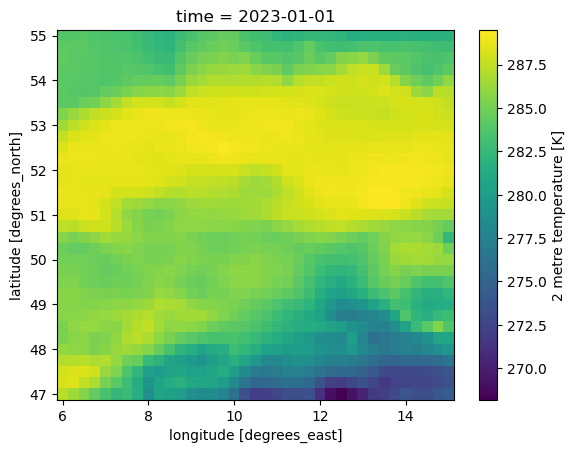

In [56]:
t2m.isel(time=0).plot()

To **convert** to a `pandas` dataframe:

In [57]:
t2m_df = t2m.to_dataframe().reset_index()

t2m_df.head()

,time,latitude,longitude,t2m
0,2023-01-01,55.0,6.00,283.692037
1,2023-01-01,55.0,6.25,283.808966
2,2023-01-01,55.0,6.50,283.837965
3,2023-01-01,55.0,6.75,283.654619
4,2023-01-01,55.0,7.00,283.447887


## Key Takeaways

In this notebook, you learned that:

- Python can load data from files using basic file handling or specialized libraries.
- `pandas` dataframes are the main structure for tabular quantitative data.
- `numpy` arrays are useful for regular numerical data such as vectors, matrices, or images.
- Beyond dataframes and arrays, Python also provides specialized libraries for other data structures. `xarray` is one example for labelled multidimensional data.
- Before analysis, it is important to inspect the structure of loaded data carefully.